In [64]:
from processor.processor import Processor as processor
from extractor.alp_client_extractor import ALPClientExtractor
from database.adatabase import ADatabase
from xgboost import XGBRegressor
from statistics import mean
import math
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv()
import os
import warnings
warnings.simplefilter(action="ignore")

In [65]:
start = datetime.now() - timedelta(days=365.25*2)
end = datetime.now()

In [90]:
key = os.getenv("APCAKEY")
secret = os.getenv("APCASECRET")
alp_client = ALPClientExtractor(key,secret)
account = alp_client.account()
cash = float(account["cash"])
factors =  ["AMZN","GOOGL","AAPL","NVDA","TSLA","MSFT","META"]
market = ADatabase("market")
holding_period = 65
stoploss = .15
positions = 10
sec = ADatabase("sec")

In [67]:
def calculate_expected_return(row, factors):
    factor_loadings = [row[factor] * row[f"{factor}_beta"] for factor in factors]
    return np.mean(factor_loadings)

In [68]:
sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",attrs={"id":"constituents"})[0].rename(columns={"Symbol":"ticker"})
sp500

,ticker,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
499,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
500,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927
501,ZION,Zions Bancorporation,Financials,Regional Banks,"Salt Lake City, Utah",2001-06-22,109380,1873


In [69]:
## download factors
factor_dfs = []
market.connect()
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period) 
        factor_dfs.append(ticker_prices)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="historical_return").reset_index()
factor_df

ticker,date,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
0,2004-06-22 00:00:00+00:00,0.285547,0.139270,NaN,NaN,0.136601,-0.110120,NaN
1,2004-06-23 00:00:00+00:00,0.303171,0.187150,NaN,NaN,0.149005,-0.084348,NaN
2,2004-06-24 00:00:00+00:00,0.283063,0.248960,NaN,NaN,0.158776,-0.085455,NaN
3,2004-06-25 00:00:00+00:00,0.332543,0.287596,NaN,NaN,0.183023,-0.083296,NaN
4,2004-06-28 00:00:00+00:00,0.274118,0.347212,NaN,NaN,0.158542,-0.129983,NaN
...,...,...,...,...,...,...,...,...
4963,2024-03-11 00:00:00+00:00,-0.105731,0.170752,0.050996,0.520961,0.087890,0.842073,-0.255320
4964,2024-03-12 00:00:00+00:00,-0.098117,0.213604,0.065221,0.575945,0.128093,1.020027,-0.258303
4965,2024-03-13 00:00:00+00:00,-0.117993,0.202036,0.020887,0.519028,0.121068,0.950644,-0.301517
4966,2024-03-14 00:00:00+00:00,-0.114916,0.212522,0.060079,0.479656,0.138334,0.851305,-0.333579


In [70]:
simulation = []
market.connect()
for ticker in tqdm(sp500["ticker"]):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices["ticker"] = ticker
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period)
        for factor in factors:
            ticker_prices[f"{factor}_covariance"] = ticker_prices["historical_return"].rolling(100).cov(ticker_prices[factor])
            ticker_prices[f"{factor}_beta"] = ticker_prices[f"{factor}_covariance"] / ticker_prices[factor].rolling(100).var()
            ticker_prices[f"{factor}_loading"] = ticker_prices[factor] * ticker_prices[f"{factor}_beta"]
        ticker_prices.dropna(inplace=True)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices["buy_price"]
        ticker_prices["expected_return"] = ticker_prices.apply(lambda row: calculate_expected_return(row, factors), axis=1)
        simulation.append(ticker_prices)
    except Exception as e:
        print(ticker,str(e))
        continue
sim = pd.concat(simulation)

  0%|                                                                                                         | 0/503 [00:00<?, ?it/s]

'date'


 12%|███████████▊                                                                                    | 62/503 [00:14<01:49,  4.04it/s]

'date'


 16%|███████████████▎                                                                                | 80/503 [00:17<01:13,  5.76it/s]

'date'


 45%|██████████████████████████████████████████▊                                                    | 227/503 [00:51<01:05,  4.21it/s]

'date'


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [01:56<00:00,  4.33it/s]


In [71]:
sim

,date,close,high,low,open,volume,adjclose,adjhigh,adjlow,adjopen,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
2222,2013-01-15 00:00:00+00:00,65.84,65.94,65.1500,65.75,296300,13.881998,13.903083,13.736515,13.863022,...,-0.029244,-0.008917,-0.083726,-0.040868,2013-01-16 00:00:00+00:00,2013-04-19 00:00:00+00:00,13.683804,14.600163,0.066967,-0.020023
2223,2013-01-16 00:00:00+00:00,64.90,65.88,64.6300,65.75,293400,13.683804,13.890432,13.626876,13.863022,...,-0.027458,-0.008799,-0.082235,-0.042751,2013-01-17 00:00:00+00:00,2013-04-22 00:00:00+00:00,14.135011,14.777776,0.045473,-0.018615
2224,2013-01-17 00:00:00+00:00,67.04,67.23,65.2300,65.28,515900,14.135011,14.175072,13.753383,13.763925,...,-0.023658,-0.008577,-0.079400,-0.041771,2013-01-18 00:00:00+00:00,2013-04-23 00:00:00+00:00,14.242542,15.511484,0.089095,-0.017489
2225,2013-01-18 00:00:00+00:00,67.55,67.81,66.4900,67.20,2097700,14.242542,14.297362,14.019047,14.168747,...,-0.027344,-0.008257,-0.075576,-0.039270,2013-01-22 00:00:00+00:00,2013-04-24 00:00:00+00:00,14.347964,15.786360,0.100251,-0.017398
2226,2013-01-22 00:00:00+00:00,68.05,68.71,66.9100,67.58,612300,14.347964,14.487122,14.107602,14.248867,...,-0.033846,-0.007974,-0.071998,-0.041343,2013-01-23 00:00:00+00:00,2013-04-25 00:00:00+00:00,14.225675,15.940714,0.120559,-0.019902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2794,2024-03-11 00:00:00+00:00,183.49,183.99,180.4200,182.62,3380995,183.490000,183.990000,180.420000,182.620000,...,0.074109,0.012607,0.403810,0.210369,2024-03-12 00:00:00+00:00,NaT,181.350000,NaN,NaN,0.084311
2795,2024-03-12 00:00:00+00:00,181.35,183.83,180.9400,183.65,2593963,181.350000,183.830000,180.940000,183.650000,...,0.113070,0.012403,0.385207,0.221858,2024-03-13 00:00:00+00:00,NaT,176.230000,NaN,NaN,0.103507
2796,2024-03-13 00:00:00+00:00,176.23,182.97,175.9900,181.60,5446616,176.230000,182.970000,175.990000,181.600000,...,0.114559,0.012078,0.370022,0.192052,2024-03-14 00:00:00+00:00,NaT,173.880000,NaN,NaN,0.084659
2797,2024-03-14 00:00:00+00:00,173.88,177.49,170.7200,177.49,6425559,173.880000,177.490000,170.720000,177.490000,...,0.139127,0.011683,0.357286,0.171374,2024-03-15 00:00:00+00:00,NaT,172.570000,NaN,NaN,0.087529


In [91]:
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades.sort_values("date",inplace=True)
iteration_trades = trades.copy().sort_values("expected_return",ascending=False).groupby("date").nth([i for i in range(positions)]).reset_index()
iteration_trades.sort_values("date",inplace=True)
iteration_trades

,index,date,close,high,low,open,volume,adjclose,adjhigh,adjlow,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
173,2336,2013-06-28 00:00:00+00:00,4.08,4.1200,4.020,4.08,13329600,4.080000,4.120000,4.020000,...,0.327216,-0.000541,-0.022582,0.001047,2013-07-01 00:00:00+00:00,2013-10-01 00:00:00+00:00,4.100000,3.860000,-0.058537,0.128321
21,1560,2013-06-28 00:00:00+00:00,24.81,25.0200,24.320,24.50,7096800,24.605333,24.813601,24.119376,...,1.981801,-0.075293,-3.141564,0.145699,2013-07-01 00:00:00+00:00,2013-10-01 00:00:00+00:00,23.524325,26.221887,0.114671,0.532147
261,2336,2013-06-28 00:00:00+00:00,60.93,61.4700,60.570,60.69,2563800,53.995413,54.473954,53.676386,...,0.281110,-0.010397,-0.433822,0.020120,2013-07-01 00:00:00+00:00,2013-10-01 00:00:00+00:00,54.323303,63.376933,0.166662,0.080873
217,2336,2013-06-28 00:00:00+00:00,224.88,234.2499,224.430,233.06,1985800,224.880000,234.249900,224.430000,...,0.414461,-0.013141,-0.548299,0.025429,2013-07-01 00:00:00+00:00,2013-10-01 00:00:00+00:00,230.140000,316.632000,0.375823,0.102333
232,2336,2013-06-28 00:00:00+00:00,74.84,76.0000,74.710,74.99,1452300,74.840000,76.000000,74.710000,...,0.355294,-0.013737,-0.573174,0.026583,2013-07-01 00:00:00+00:00,2013-10-01 00:00:00+00:00,76.270000,81.190000,0.064508,0.096306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,4980,2023-12-29 00:00:00+00:00,129.49,130.9700,129.180,129.66,2006268,129.490000,130.970000,129.180000,...,0.215659,0.012283,1.919763,0.362494,2024-01-02 00:00:00+00:00,NaT,120.140000,NaN,NaN,0.196855
81,4980,2023-12-29 00:00:00+00:00,55.81,56.4700,55.530,56.29,1465531,55.017339,55.667966,54.741316,...,0.112501,0.013695,2.140321,0.404141,2024-01-02 00:00:00+00:00,NaT,55.697540,NaN,NaN,0.200811
75,2755,2023-12-29 00:00:00+00:00,20.04,20.4900,20.010,20.27,10910495,20.040000,20.490000,20.010000,...,0.190055,0.013294,2.077659,0.392309,2024-01-02 00:00:00+00:00,NaT,18.320000,NaN,NaN,0.207582
111,4658,2023-12-29 00:00:00+00:00,166.94,169.6300,166.140,167.92,850427,166.940000,169.630000,166.140000,...,0.148484,0.011539,1.803411,0.340524,2024-01-02 00:00:00+00:00,NaT,165.380000,NaN,NaN,0.177660


In [92]:
iteration_trades["return"] = iteration_trades["return"] * (1/positions)
iteration_trades["return"] = [max(float(-stoploss/positions),x) for x in iteration_trades["return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio.iloc[:-1]
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio["return"] = portfolio["return"] + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio

,date,return,year,cumulative_return
0,2013-06-28 00:00:00+00:00,1.135692,2013,1.135692
1,2013-09-27 00:00:00+00:00,1.114159,2013,1.265341
2,2013-12-27 00:00:00+00:00,1.174508,2013,1.486152
3,2014-03-28 00:00:00+00:00,1.129420,2014,1.678491
4,2014-06-27 00:00:00+00:00,1.016973,2014,1.706979
5,2014-09-26 00:00:00+00:00,1.148290,2014,1.960107
6,2014-12-26 00:00:00+00:00,1.118505,2014,2.192390
7,2015-03-27 00:00:00+00:00,1.039469,2015,2.278922
8,2015-06-26 00:00:00+00:00,0.922532,2015,2.102378
9,2015-09-25 00:00:00+00:00,1.100634,2015,2.313949


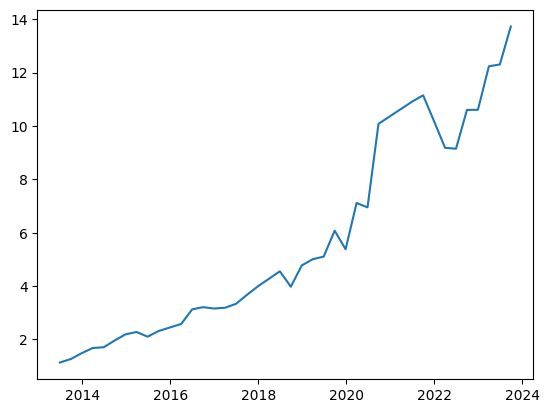

In [93]:
plt.plot(portfolio["date"].values,portfolio["cumulative_return"])

In [94]:
results = {}
results["number_of_trades"] = iteration_trades.index.size
results["standard_deviation"] = portfolio["cumulative_return"].std()
results["coefficient_of_variance"] = portfolio["cumulative_return"].std() / portfolio["cumulative_return"].mean()
results["sharpe"] = portfolio["cumulative_return"].iloc[-1] / portfolio["cumulative_return"].std()
results["return"] = portfolio["cumulative_return"].iloc[-1]
results = pd.DataFrame([results]).round(4).to_dict("records")[0]
results

{'number_of_trades': 390,
 'standard_deviation': 3.7829,
 'coefficient_of_variance': 0.6734,
 'sharpe': 3.6298,
 'return': 13.7315}

In [95]:
recommendations = iteration_trades[iteration_trades["date"]==iteration_trades["date"].max()].copy()
recommendations

,index,date,close,high,low,open,volume,adjclose,adjhigh,adjlow,...,MSFT_loading,META_covariance,META_beta,META_loading,buy_date,sell_date,buy_price,sell_price,return,expected_return
56,4980,2023-12-29 00:00:00+00:00,18.54,18.8800,18.530,18.64,25436669,18.540000,18.880000,18.530000,...,0.177243,0.020427,3.192498,0.602815,2024-01-02 00:00:00+00:00,NaT,17.290000,NaN,-0.015,0.303443
103,4710,2023-12-29 00:00:00+00:00,124.09,124.7800,123.650,123.78,1301730,124.090000,124.780000,123.650000,...,0.444105,0.009255,1.446456,0.273123,2024-01-02 00:00:00+00:00,NaT,123.090000,NaN,-0.015,0.182827
99,4186,2023-12-29 00:00:00+00:00,216.98,219.7991,215.885,218.77,524182,216.980000,219.799100,215.885000,...,0.524859,0.008938,1.396863,0.263759,2024-01-02 00:00:00+00:00,NaT,209.110000,NaN,-0.015,0.188910
95,4642,2023-12-29 00:00:00+00:00,151.79,155.1550,151.350,154.06,1307377,151.790000,155.155000,151.350000,...,0.407131,0.010272,1.605374,0.303131,2024-01-02 00:00:00+00:00,NaT,148.760000,NaN,-0.015,0.191922
91,4809,2023-12-29 00:00:00+00:00,630.78,635.6200,620.850,631.77,276933,630.780000,635.620000,620.850000,...,0.309934,0.011398,1.781446,0.336377,2024-01-02 00:00:00+00:00,NaT,604.000000,NaN,-0.015,0.194235
86,4980,2023-12-29 00:00:00+00:00,129.49,130.9700,129.180,129.66,2006268,129.490000,130.970000,129.180000,...,0.215659,0.012283,1.919763,0.362494,2024-01-02 00:00:00+00:00,NaT,120.140000,NaN,-0.015,0.196855
81,4980,2023-12-29 00:00:00+00:00,55.81,56.4700,55.530,56.29,1465531,55.017339,55.667966,54.741316,...,0.112501,0.013695,2.140321,0.404141,2024-01-02 00:00:00+00:00,NaT,55.697540,NaN,-0.015,0.200811
75,2755,2023-12-29 00:00:00+00:00,20.04,20.4900,20.010,20.27,10910495,20.040000,20.490000,20.010000,...,0.190055,0.013294,2.077659,0.392309,2024-01-02 00:00:00+00:00,NaT,18.320000,NaN,-0.015,0.207582
111,4658,2023-12-29 00:00:00+00:00,166.94,169.6300,166.140,167.92,850427,166.940000,169.630000,166.140000,...,0.148484,0.011539,1.803411,0.340524,2024-01-02 00:00:00+00:00,NaT,165.380000,NaN,-0.015,0.177660
105,4194,2023-12-29 00:00:00+00:00,40.23,40.6600,39.975,40.53,8624237,40.133802,40.562774,39.879412,...,0.079545,0.012374,1.933892,0.365162,2024-01-02 00:00:00+00:00,NaT,40.353276,NaN,-0.015,0.181666


In [96]:
# try:
#     positions = recommendations.index.size
#     notional = math.floor(float(cash/positions),2)
#     for row in recommendations.iterrows():
#         ticker = row[1]["ticker"]
#         print(alp_client.buy(ticker,notional))
# except Exception as e:
#     print(str(e))